### Fourier Matrix

In [14]:
import numpy as np
import pandas as pd
def fourier_matrix(n):
    e = np.exp(-2j*np.pi/n)
    F = np.zeros((n,n), dtype=complex)
    for i in range(n):
        for j in range(n):
            F[i,j] = e**(i*j)
            F_new = pd.DataFrame(F)
    return F_new

if __name__=='__main__':
    n= int(input('The size of matrix:'))
    print(fourier_matrix(n))

          0         1         2         3
0  1.0+0.0j  1.0+0.0j  1.0+0.0j  1.0+0.0j
1  1.0+0.0j  0.0-1.0j -1.0-0.0j -0.0+1.0j
2  1.0+0.0j -1.0-0.0j  1.0+0.0j -1.0-0.0j
3  1.0+0.0j -0.0+1.0j -1.0-0.0j  0.0-1.0j


### First Step of FFT (Three Matrix Generation)

In [13]:
def fourier_matrix(n):
    omega = np.exp(-2j*np.pi/n)
    F = np.zeros((n,n), dtype=complex)
    for i in range(n):
        for j in range(n):
            F[i,j] = omega**(i*j)
    return F

def permutation_matrix(n):
    P = np.zeros((n,n))
    row = 0
    for i in range(0,n,2):
        P[row, i] = 1
        row += 1
    for i in range(1,n,2):
        P[row, i] = 1
        row += 1
    return P

def I_D_matrix(n):
    omega = np.exp(-2j*np.pi/n)
    I = np.eye(n//2)
    D = np.zeros((n//2,n//2),dtype = complex)
    for i in range(n//2):
        D[i,i] = omega**i
    ID = np.hstack((I,D))
    ID_= np.hstack((I,-D))
    ID_matrix = np.vstack((ID,ID_))
    return ID_matrix

def F_n2(n):
    Z = np.zeros((n//2,n//2),dtype = int)
    F_n2 = fourier_matrix(n//2)
    F1 = np.hstack([F_n2,Z])
    F2 = np.hstack([Z,F_n2])
    final = np.vstack([F1,F2])
    return final

n = int(input('The size of matrix:'))
F = fourier_matrix(n)
A = I_D_matrix(n)
B = F_n2(n)
P = permutation_matrix(n)

print('F = \n',F)
fft = np.dot(np.dot(A,B),P)
print('ID matrix = \n',A)
print('F_n2 matrix = \n',B)
print('Permutation matrix = \n',P)
print('FFT matrix = \n',fft)


c = np.array([1,0,1,0],dtype = complex)

fft_c = np.dot(fft,c)

F_c = np.dot(F,c)

print('F_c = \n',F_c)
print('fft_c = \n',fft_c)

print('Compare F_c and fft_c:',np.allclose(F_c,fft_c))

F = 
 [[ 1.0000000e+00+0.0000000e+00j  1.0000000e+00+0.0000000e+00j
   1.0000000e+00+0.0000000e+00j  1.0000000e+00+0.0000000e+00j]
 [ 1.0000000e+00+0.0000000e+00j  6.1232340e-17-1.0000000e+00j
  -1.0000000e+00-1.2246468e-16j -1.8369702e-16+1.0000000e+00j]
 [ 1.0000000e+00+0.0000000e+00j -1.0000000e+00-1.2246468e-16j
   1.0000000e+00+2.4492936e-16j -1.0000000e+00-3.6739404e-16j]
 [ 1.0000000e+00+0.0000000e+00j -1.8369702e-16+1.0000000e+00j
  -1.0000000e+00-3.6739404e-16j  5.5109106e-16-1.0000000e+00j]]
ID matrix = 
 [[ 1.000000e+00+0.j  0.000000e+00+0.j  1.000000e+00+0.j  0.000000e+00+0.j]
 [ 0.000000e+00+0.j  1.000000e+00+0.j  0.000000e+00+0.j  6.123234e-17-1.j]
 [ 1.000000e+00+0.j  0.000000e+00+0.j -1.000000e+00-0.j -0.000000e+00-0.j]
 [ 0.000000e+00+0.j  1.000000e+00+0.j -0.000000e+00-0.j -6.123234e-17+1.j]]
F_n2 matrix = 
 [[ 1.+0.0000000e+00j  1.+0.0000000e+00j  0.+0.0000000e+00j
   0.+0.0000000e+00j]
 [ 1.+0.0000000e+00j -1.-1.2246468e-16j  0.+0.0000000e+00j
   0.+0.0000000e+00j]


## Shift and Circulant Matrix

In [15]:
# Shift and Circulant Matrix
import numpy as np
def shift_matrix(n, shift = 1):
    S = np.eye(n,dtype = int)
    S = np.roll(S, shift, axis = 1)
    return S

def circulant_matrix(n, c):
    C = np.zeros((n,n),dtype = int)
    for i in range(n):
        C[i] = np.roll(c,i)
    return C

if __name__ == '__main__':
    n = int(input('The size of matrix:'))
    shift = int(input('The shift:'))
    S = shift_matrix(n,shift)
    print('Shift matrix = \n',S)

    c = input('The elements of circulant matrix:').split()
    circulant = circulant_matrix(len(c),c)
    print('Circulant matrix = \n',circulant)

Shift matrix = 
 [[0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]
Circulant matrix = 
 [[ 2 -1  0 -1]
 [-1  2 -1  0]
 [ 0 -1  2 -1]
 [-1  0 -1  2]]


### Eigenvectors and eigenvalues of the circulant matrix

In [26]:
import numpy as np  
  
def circulant_matrix(n, c):  
    C = np.zeros((n, n), dtype=complex)  
    for i in range(n):  
        C[i] = np.roll(c, i)  
    return C  
  
def permutation_matrix(n):  
    P = np.eye(n, dtype=int)  
    return np.roll(P, 1, axis=1)  
  
# Example vector c for the circulant matrix  
c = np.array([2,-1,0,-1], dtype=int)  
  
# Create circulant matrix  
C = circulant_matrix(4, c)  
print('Circulant matrix = \n', C)  
  
# Compute eigenvalues and eigenvectors of the circulant matrix  
eig_val_C, eig_vect_C = np.linalg.eig(C)  
print('The eigenvalues of C = \n', eig_val_C)  
print('The eigenvectors of C = \n', eig_vect_C)  
  
# Create permutation matrix  
P = permutation_matrix(4)  
  
# Compute eigenvalues and eigenvectors of the permutation matrix  
eig_val_P, eig_vect_P = np.linalg.eig(P)  
print('The eigenvalues of P = \n', eig_val_P)  
print('The eigenvectors of P = \n', eig_vect_P)  
# Norm of the eigenvectors
norm_C = np.linalg.norm(eig_vect_C, axis=0)
norm_P = np.linalg.norm(eig_vect_P, axis=0)

print('The norm of the eigenvectors of C = \n', norm_C)
print('The norm of the eigenvectors of P = \n', norm_P)

Circulant matrix = 
 [[ 2.+0.j -1.+0.j  0.+0.j -1.+0.j]
 [-1.+0.j  2.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  2.+0.j -1.+0.j]
 [-1.+0.j  0.+0.j -1.+0.j  2.+0.j]]
The eigenvalues of C = 
 [-2.60162711e-16+0.j  2.00000000e+00+0.j  4.00000000e+00+0.j
  2.00000000e+00+0.j]
The eigenvectors of C = 
 [[ 5.00000000e-01-0.j  7.07106781e-01+0.j  5.00000000e-01+0.j
  -3.70074342e-17-0.j]
 [ 5.00000000e-01+0.j -4.69424351e-16-0.j -5.00000000e-01+0.j
   7.07106781e-01+0.j]
 [ 5.00000000e-01-0.j -7.07106781e-01-0.j  5.00000000e-01+0.j
  -2.77011058e-16-0.j]
 [ 5.00000000e-01-0.j -2.19624170e-16-0.j -5.00000000e-01+0.j
  -7.07106781e-01-0.j]]
The eigenvalues of P = 
 [-1.00000000e+00+0.j  8.32667268e-17+1.j  8.32667268e-17-1.j
  1.00000000e+00+0.j]
The eigenvectors of P = 
 [[ 5.00000000e-01+0.00000000e+00j  2.63941871e-16-5.00000000e-01j
   2.63941871e-16+5.00000000e-01j  5.00000000e-01+0.00000000e+00j]
 [-5.00000000e-01+0.00000000e+00j  5.00000000e-01-1.34144886e-16j
   5.00000000e-01+1.34144886e-

### To find: Multiply F times the vector c in the top row of C to find the eigenvalues of circulant matrix C.

In [27]:
# Compute the eigenvalues of the circulant matrix C
def fourier_matrix(n):
    omega = np.exp(-2j*np.pi/n)
    F = np.zeros((n,n), dtype=complex)
    for i in range(n):
        for j in range(n):
            F[i,j] = omega**(i*j)
    return F
c = np.array([2,-1,0,-1], dtype=int)
eig_val_C = np.dot(fourier_matrix(4), c)
print('The eigenvalues of C = \n', eig_val_C)


The eigenvalues of C = 
 [0.+0.0000000e+00j 2.+0.0000000e+00j 4.+4.8985872e-16j 2.+0.0000000e+00j]


### To make k clusters using the k-means algorithm. Make 3 clusters using IRIS data set.

Centroids = 
[[ 1.18671078  0.12437601]
 [-0.97822861  0.90390597]
 [-0.05899721 -0.90478291]]
 Labels = 
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 0 0 0 0 2 2 2 2 2 2 2 1 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 2 0 0
 2 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 2 0 0 0 2 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


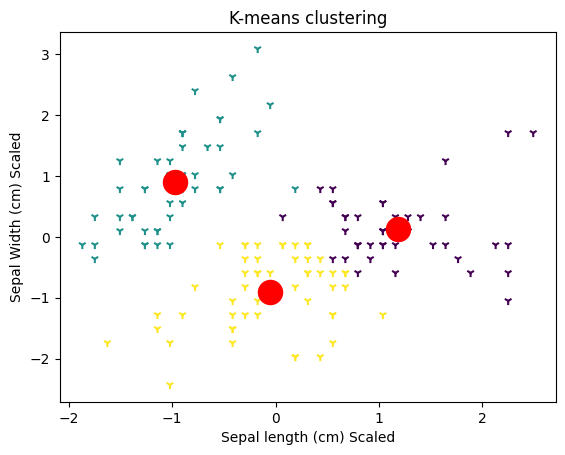

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

def init_centroids(X, k):
    # Randomly init the centroids by choosing k unique points from X
    indices = np.random.choice(X.shape[0], k, replace=False) # Randomly choose k indices
    return X[indices]

def compute_distances(X,centroids, p = 2):
    distances = np.zeros((X.shape[0], centroids.shape[0])) # Initialize the distance matrix
    for i, centroid in enumerate(centroids):
        distances[:,i] = np.sum(np.abs(X-centroid)**p, axis = 1) ** (1/p)
    return distances

def assign_clusters(distances):
    return np.argmin(distances, axis = 1)

def update_centroids(X, labels, k):
    # Update the centroids by taking the mean of all data points in the cluster
    centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        points = X[labels == i]
        if len(points) > 0:
            centroids[i] = points.mean(axis = 0)
    return centroids

def kmeans(X,k, max_iters = 1000, tol = 1e-4, p = 2, n_init= 10):
    best_inertia = np.inf
    best_labels = None
    best_centroids = None

    for _ in range(n_init):
        centroids = init_centroids(X, k)
        for _ in range(max_iters):
            old_centroids = centroids
            distances = compute_distances(X, centroids, p)
            labels = assign_clusters(distances)
            centroids = update_centroids(X, labels, k)
            if np.all(np.abs(centroids - old_centroids) < tol):
                break

        inertia = np.sum(np.min(compute_distances(X, centroids, p), axis=1)**2)
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels
            best_centroids = centroids

    return best_labels, best_centroids

def plot_clusters(X, labels, centroids):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', alpha=0.5)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.9)
    plt.title('Data points and cluster centroids')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()

iris = load_iris()
X,y = iris.data, iris.target
# print(X[:,:2]) # Display the first two columns of X
scaler = StandardScaler()
X_std = scaler.fit_transform(X[:,:2])

k = 3
p = 2
n_init = 10
labels, centroids = kmeans(X_std, k, p = p, n_init = n_init)
print(f'Centroids = \n{centroids}\n Labels = \n{labels}')
plt.scatter(X_std[:,0], X_std[:,1], c = labels, marker='1', cmap = 'viridis')
plt.scatter(centroids[:,0], centroids[:,1], c = 'red', s = 300)
plt.title('K-means clustering')
plt.xlabel('Sepal length (cm) Scaled')
plt.ylabel('Sepal Width (cm) Scaled')
plt.show()

## Direct Line Method for Gradient Descent

In [39]:
import numpy as np
# Define the function and its gradient
def f(x, y):
    return (x-5)**2 + (y+1)**2

def grad_f(x, y):
    return np.array([2*(x-5), 2*(y+1)])

# Parameters for gradient descent
learning_rate = 0.1  # Adjust as needed
max_iters = 1000     # Maximum number of iterations
tolerance = 1e-7     # Tolerance for stopping criterion

# Initial guess
x0 = 2
y0 = 3

# Gradient descent loop
x = x0
y = y0
iter = 0
while iter < max_iters:
    # Compute gradient
    gradient = grad_f(x, y)
    
    # Update parameters
    x_new = x - learning_rate * gradient[0]
    y_new = y - learning_rate * gradient[1]
    
    # Check convergence
    if np.linalg.norm([x_new - x, y_new - y]) < tolerance: 
        break
    
    # Update for next iteration
    x = x_new
    y = y_new
    
    # Increment iteration counter
    iter += 1

# Display results
print(f"Minimum found at (x, y) = ({x:.4f}, {y:.4f})")
print(f"Minimum value of f(x, y) = {f(x, y):.4f}")
print (f'Number of iterations: {iter}')

Minimum found at (x, y) = (5.0000, -1.0000)
Minimum value of f(x, y) = 0.0000
Number of iterations: 73


## Backtracking Method for Gradient Descent

In [41]:
import numpy as np

def cost_function(x, y):
    return (x-5)**2 + (y+1)**2

def gradient(x, y):
    grad_x, grad_y = 2*(x-5), 2*(y+1)
    return grad_x, grad_y

def backtracking_line_search(x, y, alpha=1/3, lr=0.33, tol=1e-6, max_iters=100000):
    step_size = 1
    for i in range(max_iters):
        grad_x, grad_y = gradient(x, y)
        grad_norm = np.sqrt(grad_x**2 + grad_y**2)
        if grad_norm < tol: # Convergence criterion
            break
        while True:
            new_x = x - step_size * grad_x
            new_y = y - step_size * grad_y
            if cost_function(new_x, new_y) <= cost_function(x, y) - alpha * step_size * grad_norm**2:
                break
            step_size *= lr
        x, y = new_x, new_y
    print(f'Number of Iterations: {i}')
    return x, y

# Example usage
initial_x, initial_y = 1.0, 1.0
optimal_x, optimal_y = backtracking_line_search(initial_x, initial_y)
print(f"Optimal (x, y): ({optimal_x:.4f}, {optimal_y:.4f}), f(x,y)={cost_function(optimal_x, optimal_y):.4f}")


Number of Iterations: 15
Optimal (x, y): (5.0000, -1.0000), f(x,y)=0.0000
